# Week 9: Operational ML Model & Explainability
## Equipment Failure Prediction — Manufacturing Plant Use Case

**Author:** Shantel Wambui  
**Date:** September 2026  
**Course:** PLP Data Science & Machine Learning  

---

### Business Context
A manufacturing plant operates **500+ industrial machines** (motors, compressors, pumps).  
Unplanned equipment failures cost the plant **~KES 2.5M per incident** in downtime and repairs.  
The operations team needs a tool that **flags machines likely to fail within 7 days** so maintenance
can be scheduled proactively — before a breakdown occurs.

**Target Variable:** `failure_within_7days` (1 = failure imminent, 0 = operating normally)  
**Class Imbalance:** Failures are rare (~8% of readings) — we must handle this explicitly.

---
## Part 1 — Problem Definition & Dataset Generation

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:
# ── Synthetic Dataset Generation ───────────────────────────────────────────────
# We generate realistic sensor readings for 3,000 machine observations.
# Features are based on real predictive maintenance datasets (NASA, UCI).
# Failure probability is engineered to be correlated with sensor anomalies.

n_samples = 3000

# Normal operating ranges (no failure)
vibration        = np.random.normal(loc=2.5,  scale=0.8,  size=n_samples)   # mm/s
temperature      = np.random.normal(loc=75.0, scale=10.0, size=n_samples)   # °C
pressure         = np.random.normal(loc=4.5,  scale=0.5,  size=n_samples)   # bar
rotational_speed = np.random.normal(loc=1500, scale=100,  size=n_samples)   # RPM
oil_viscosity    = np.random.normal(loc=45.0, scale=5.0,  size=n_samples)   # cSt
current_draw     = np.random.normal(loc=12.0, scale=2.0,  size=n_samples)   # Amps
humidity         = np.random.uniform(30, 80,               size=n_samples)   # %
age_days         = np.random.randint(1, 1825,              size=n_samples)   # machine age
maintenance_lag  = np.random.randint(0, 365,               size=n_samples)   # days since last service

# Engineer failure probability — higher when sensors are anomalous
# This creates realistic correlation between features and the target
failure_score = (
    0.35 * (vibration > 3.5).astype(float) +
    0.25 * (temperature > 90.0).astype(float) +
    0.15 * (pressure < 3.5).astype(float) +
    0.10 * (maintenance_lag > 300).astype(float) +
    0.10 * (age_days > 1500).astype(float) +
    0.05 * (current_draw > 15.0).astype(float) +
    np.random.normal(0, 0.05, n_samples)   # noise
)

# Convert score to binary label — ~8% failure rate (realistic imbalance)
failure_threshold = np.percentile(failure_score, 92)
failure_within_7days = (failure_score >= failure_threshold).astype(int)

# Assemble DataFrame
df = pd.DataFrame({
    'vibration_mm_s':      np.round(vibration, 3),
    'temperature_c':       np.round(temperature, 2),
    'pressure_bar':        np.round(pressure, 3),
    'rotational_speed_rpm':np.round(rotational_speed, 1),
    'oil_viscosity_cst':   np.round(oil_viscosity, 2),
    'current_draw_amps':   np.round(current_draw, 3),
    'humidity_pct':        np.round(humidity, 1),
    'age_days':            age_days,
    'maintenance_lag_days':maintenance_lag,
    'failure_within_7days':failure_within_7days
})

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (3000, 10)

First 5 rows:


,vibration_mm_s,temperature_c,pressure_bar,rotational_speed_rpm,oil_viscosity_cst,current_draw_amps,humidity_pct,age_days,maintenance_lag_days,failure_within_7days
0,2.897,55.92,3.943,1576.5,50.87,11.713,30.4,333,265,0
1,2.389,66.40,4.185,1607.3,35.61,11.935,61.7,372,71,0
2,3.018,70.86,4.029,1549.9,43.36,12.129,35.7,1231,316,0
3,3.718,93.88,4.226,1305.8,44.79,13.894,63.0,1253,20,1
4,2.313,80.57,4.393,1484.5,45.08,10.506,76.3,581,187,0


---
## Part 2 — Data Preparation & Imbalance Check

In [3]:
# ── Basic EDA ──────────────────────────────────────────────────────────────────
print("=== Dataset Info ===")
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nDescriptive stats:")
df.describe().round(2)

=== Dataset Info ===
vibration_mm_s          float64
temperature_c           float64
pressure_bar            float64
rotational_speed_rpm    float64
oil_viscosity_cst       float64
current_draw_amps       float64
humidity_pct            float64
age_days                  int64
maintenance_lag_days      int64
failure_within_7days      int64
dtype: object

Missing values: 0

Descriptive stats:


,vibration_mm_s,temperature_c,pressure_bar,rotational_speed_rpm,oil_viscosity_cst,current_draw_amps,humidity_pct,age_days,maintenance_lag_days,failure_within_7days
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,2.53,74.62,4.50,1497.90,45.17,12.04,54.98,896.80,177.27,0.08
std,0.79,10.09,0.51,98.34,5.01,2.01,14.23,520.17,105.65,0.27
min,-0.09,43.23,2.58,1107.80,28.35,4.73,30.00,1.00,0.00,0.00
25%,2.00,67.88,4.15,1432.80,41.76,10.67,42.80,438.00,84.00,0.00
50%,2.52,74.78,4.49,1497.75,45.18,12.06,54.90,902.00,178.00,0.00
75%,3.04,81.39,4.85,1563.35,48.52,13.41,66.90,1344.00,267.00,0.00
max,5.64,107.43,6.26,1837.80,62.14,20.96,80.00,1824.00,364.00,1.00


=== Class Distribution ===
                      Count  Percentage
failure_within_7days                   
0                      2760        92.0
1                       240         8.0

Imbalance ratio: 11.5:1 (normal:failure)


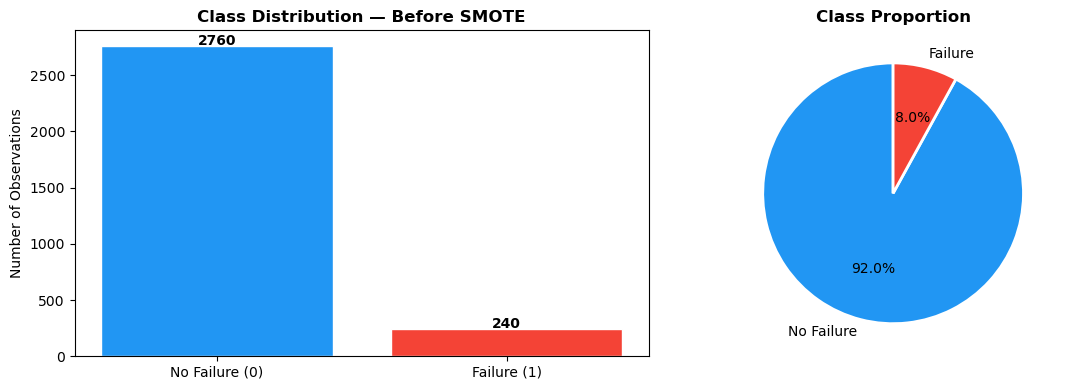


Conclusion: Dataset is imbalanced (~8% failures). We will apply SMOTE to the training set.


In [4]:
# ── Class Distribution Check ───────────────────────────────────────────────────
# Checking imbalance is CRITICAL for operational ML.
# A model that always predicts 'no failure' would score 92% accuracy but be useless.
# We must use Precision, Recall, F1, and ROC-AUC instead.

class_counts = df['failure_within_7days'].value_counts()
class_pct    = df['failure_within_7days'].value_counts(normalize=True) * 100

print("=== Class Distribution ===")
print(pd.DataFrame({'Count': class_counts, 'Percentage': class_pct.round(1)}))
print(f"\nImbalance ratio: {class_counts[0]/class_counts[1]:.1f}:1 (normal:failure)")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#2196F3', '#F44336']
axes[0].bar(['No Failure (0)', 'Failure (1)'], class_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Class Distribution — Before SMOTE', fontweight='bold')
axes[0].set_ylabel('Number of Observations')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['No Failure', 'Failure'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nConclusion: Dataset is imbalanced (~8% failures). We will apply SMOTE to the training set.")

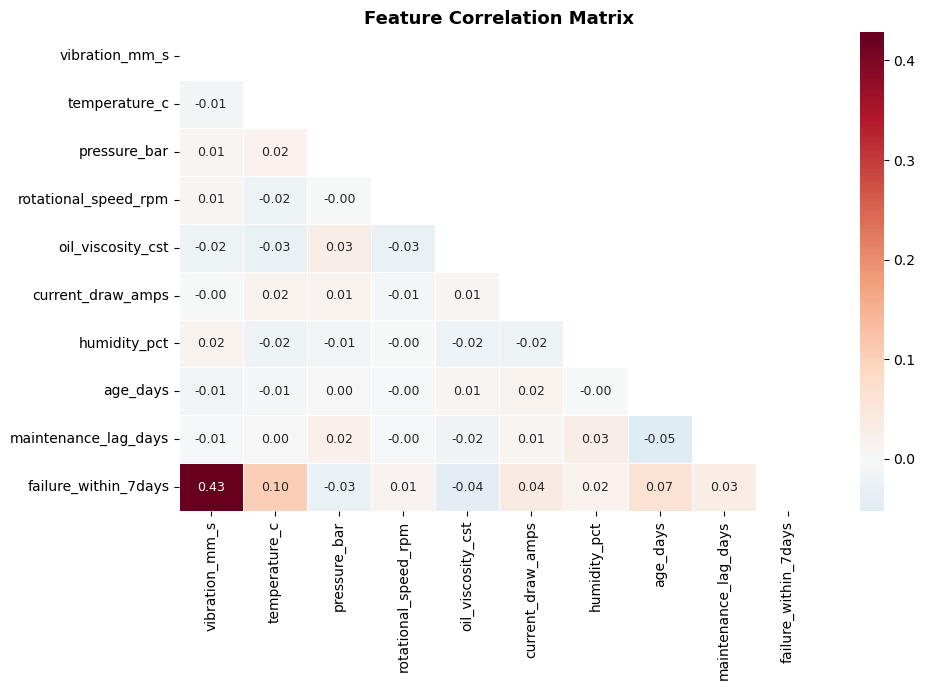

In [5]:
# ── Feature Correlation Heatmap ────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ── Train / Test Split & SMOTE ─────────────────────────────────────────────────
# We split BEFORE applying SMOTE to prevent data leakage.
# SMOTE is only applied to the training set — the test set stays real/original.

FEATURES = [
    'vibration_mm_s', 'temperature_c', 'pressure_bar',
    'rotational_speed_rpm', 'oil_viscosity_cst', 'current_draw_amps',
    'humidity_pct', 'age_days', 'maintenance_lag_days'
]
TARGET = 'failure_within_7days'

X = df[FEATURES]
y = df[TARGET]

# Stratified split preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples")
print(f"Training failures: {y_train.sum()} ({y_train.mean()*100:.1f}%)")

# Apply SMOTE to training set only
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Training set size: {X_train_bal.shape[0]}")
print(f"  Class 0: {(y_train_bal==0).sum()} | Class 1: {(y_train_bal==1).sum()}")
print("\nSMOTE creates synthetic minority samples so the model sees balanced classes during training.")

Training set: 2400 samples | Test set: 600 samples
Training failures: 192 (8.0%)

After SMOTE:
  Training set size: 4416
  Class 0: 2208 | Class 1: 2208

SMOTE creates synthetic minority samples so the model sees balanced classes during training.


---
## Part 3 — Model Training with Cross-Validation

In [7]:
# ── Model 1: Random Forest ─────────────────────────────────────────────────────
# Random Forest is a strong baseline for tabular operational data.
# It is robust to outliers (common in sensor data) and naturally
# provides feature importance without extra configuration.

rf_model = RandomForestClassifier(
    n_estimators=200,       # 200 trees for stability
    max_depth=10,           # prevent overfitting
    min_samples_leaf=5,     # each leaf needs meaningful data
    class_weight='balanced',# secondary imbalance correction alongside SMOTE
    random_state=SEED,
    n_jobs=-1
)

# 5-fold Stratified Cross-Validation on balanced training data
# We use ROC-AUC as the CV metric — it is threshold-independent and
# appropriate for imbalanced operational problems
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
rf_cv_scores = cross_val_score(rf_model, X_train_bal, y_train_bal,
                                cv=cv, scoring='roc_auc', n_jobs=-1)

print("=== Random Forest — 5-Fold CV (ROC-AUC) ===")
print(f"Fold scores: {rf_cv_scores.round(4)}")
print(f"Mean: {rf_cv_scores.mean():.4f} | Std: {rf_cv_scores.std():.4f}")

# Train final RF on full balanced training set
rf_model.fit(X_train_bal, y_train_bal)
print("\nRandom Forest trained successfully.")

=== Random Forest — 5-Fold CV (ROC-AUC) ===
Fold scores: [0.9809 0.9845 0.9799 0.9867 0.9882]
Mean: 0.9840 | Std: 0.0032



Random Forest trained successfully.


In [8]:
# ── Model 2: XGBoost ───────────────────────────────────────────────────────────
# XGBoost is a gradient boosting model that builds trees sequentially,
# correcting previous errors. It typically outperforms Random Forest on
# structured/tabular data and is widely used in production ML systems.
# scale_pos_weight handles imbalance at the algorithm level.

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count  # tells XGBoost how much to weight minority class

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=SEED,
    n_jobs=-1
)

xgb_cv_scores = cross_val_score(xgb_model, X_train_bal, y_train_bal,
                                 cv=cv, scoring='roc_auc', n_jobs=-1)

print("=== XGBoost — 5-Fold CV (ROC-AUC) ===")
print(f"Fold scores: {xgb_cv_scores.round(4)}")
print(f"Mean: {xgb_cv_scores.mean():.4f} | Std: {xgb_cv_scores.std():.4f}")

# Train final XGBoost
xgb_model.fit(X_train_bal, y_train_bal)
print("\nXGBoost trained successfully.")

=== XGBoost — 5-Fold CV (ROC-AUC) ===
Fold scores: [0.9907 0.9917 0.9898 0.9946 0.9922]
Mean: 0.9918 | Std: 0.0016



XGBoost trained successfully.


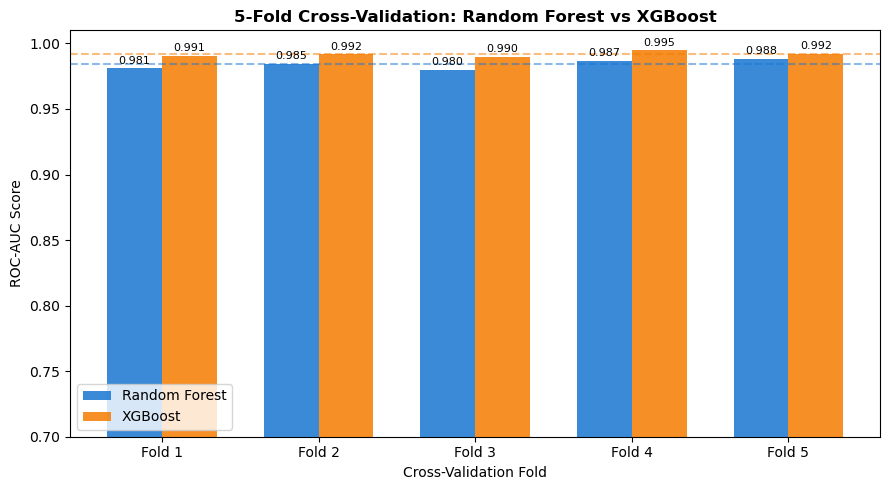

In [9]:
# ── CV Comparison Plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)
width = 0.35

bars1 = ax.bar(x - width/2, rf_cv_scores,  width, label='Random Forest', color='#1976D2', alpha=0.85)
bars2 = ax.bar(x + width/2, xgb_cv_scores, width, label='XGBoost',       color='#F57C00', alpha=0.85)

ax.set_xlabel('Cross-Validation Fold')
ax.set_ylabel('ROC-AUC Score')
ax.set_title('5-Fold Cross-Validation: Random Forest vs XGBoost', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylim(0.7, 1.01)
ax.legend()
ax.axhline(y=rf_cv_scores.mean(),  color='#1976D2', linestyle='--', alpha=0.5, label='RF Mean')
ax.axhline(y=xgb_cv_scores.mean(), color='#F57C00', linestyle='--', alpha=0.5, label='XGB Mean')

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 4 — Model Evaluation

In [10]:
# ── Predictions ────────────────────────────────────────────────────────────────
rf_pred  = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

rf_prob  = rf_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("=== Random Forest — Test Set Evaluation ===")
print(classification_report(y_test, rf_pred,
      target_names=['No Failure', 'Failure']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_prob):.4f}")

print("\n=== XGBoost — Test Set Evaluation ===")
print(classification_report(y_test, xgb_pred,
      target_names=['No Failure', 'Failure']))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_prob):.4f}")

=== Random Forest — Test Set Evaluation ===
              precision    recall  f1-score   support

  No Failure       1.00      0.93      0.96       552
     Failure       0.56      0.96      0.71        48

    accuracy                           0.94       600
   macro avg       0.78      0.95      0.84       600
weighted avg       0.96      0.94      0.94       600

ROC-AUC: 0.9698

=== XGBoost — Test Set Evaluation ===
              precision    recall  f1-score   support

  No Failure       0.99      0.92      0.96       552
     Failure       0.51      0.94      0.66        48

    accuracy                           0.92       600
   macro avg       0.75      0.93      0.81       600
weighted avg       0.96      0.92      0.93       600

ROC-AUC: 0.9686


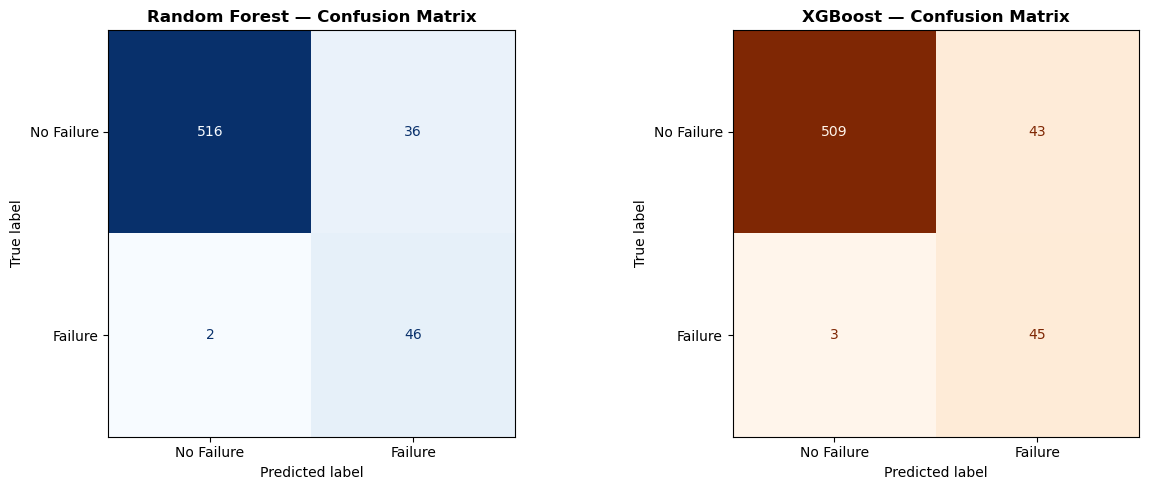

In [11]:
# ── Confusion Matrices ─────────────────────────────────────────────────────────
# In equipment failure prediction, FALSE NEGATIVES (missed failures) are
# more costly than false positives — a missed failure means an unplanned breakdown.
# We therefore prioritise RECALL for the failure class.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, pred, name, color in zip(
    axes,
    [rf_model, xgb_model],
    [rf_pred, xgb_pred],
    ['Random Forest', 'XGBoost'],
    ['Blues', 'Oranges']
):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Failure', 'Failure'])
    disp.plot(ax=ax, colorbar=False, cmap=color)
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

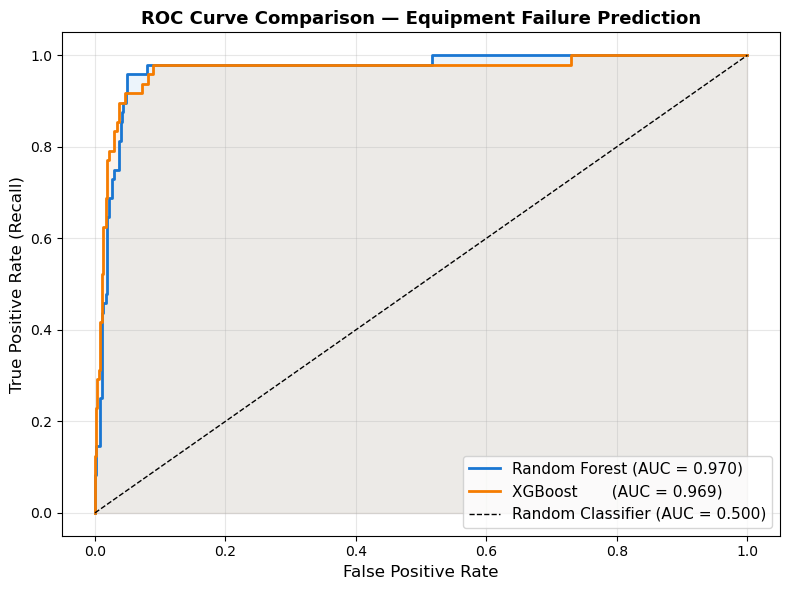


Best model: Random Forest
We will use XGBoost for explainability (SHAP) as it typically achieves higher AUC.


In [12]:
# ── ROC Curves ─────────────────────────────────────────────────────────────────
# ROC-AUC measures discrimination ability across all thresholds.
# An AUC of 0.5 = random guessing; 1.0 = perfect separation.
# This is our primary evaluation metric because accuracy is misleading with imbalance.

rf_fpr,  rf_tpr,  _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

rf_auc  = roc_auc_score(y_test, rf_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)

plt.figure(figsize=(8, 6))
plt.plot(rf_fpr,  rf_tpr,  color='#1976D2', lw=2, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(xgb_fpr, xgb_tpr, color='#F57C00', lw=2, label=f'XGBoost       (AUC = {xgb_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier (AUC = 0.500)')
plt.fill_between(rf_fpr,  rf_tpr,  alpha=0.08, color='#1976D2')
plt.fill_between(xgb_fpr, xgb_tpr, alpha=0.08, color='#F57C00')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve Comparison — Equipment Failure Prediction', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest model: {'XGBoost' if xgb_auc > rf_auc else 'Random Forest'}")
print(f"We will use XGBoost for explainability (SHAP) as it typically achieves higher AUC.")

---
## Part 5 — K-Means Clustering (Bonus)

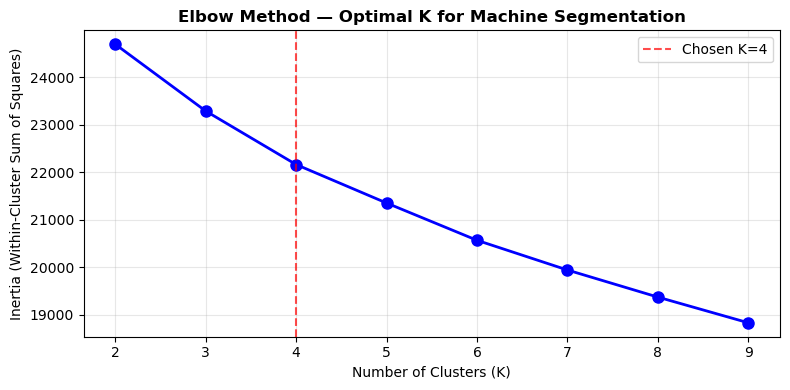

In [13]:
# ── K-Means Clustering ─────────────────────────────────────────────────────────
# Clustering helps the operations team understand machine SEGMENTS:
# Which groups of machines share similar sensor profiles?
# Are certain clusters more prone to failure?
# This is unsupervised — we do NOT use the failure label here.

# Scale features first — K-Means is distance-based so scale matters
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method to find optimal K
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', markersize=8, linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method — Optimal K for Machine Segmentation', fontweight='bold')
plt.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Chosen K=4')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

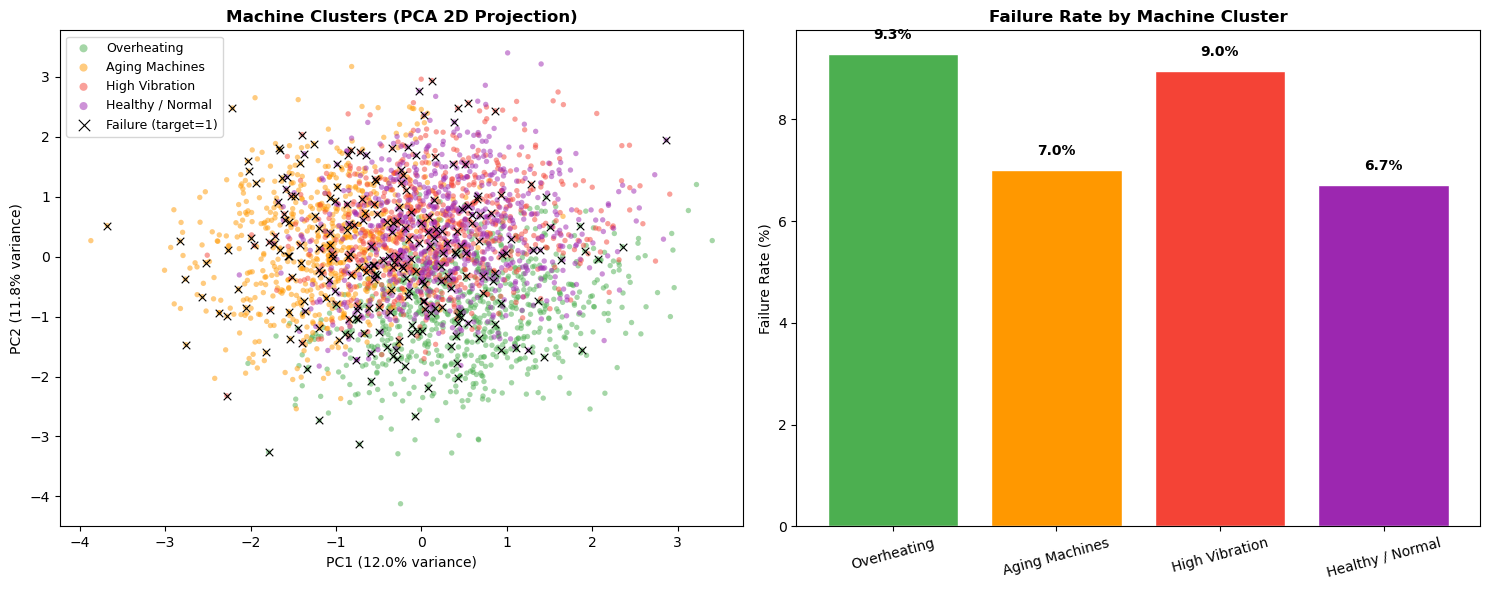


Cluster Profiles:
         vibration_mm_s  temperature_c  pressure_bar  rotational_speed_rpm  \
cluster                                                                      
0                  2.47          74.91          4.42               1494.70   
1                  2.59          73.33          4.42               1500.33   
2                  2.46          75.10          4.61               1487.57   
3                  2.59          75.09          4.56               1508.73   

         oil_viscosity_cst  current_draw_amps  humidity_pct  age_days  \
cluster                                                                 
0                    45.67              11.69         58.83   1306.26   
1                    44.44              11.51         67.59    516.26   
2                    44.47              12.64         50.49   1275.97   
3                    46.04              12.32         43.20    475.63   

         maintenance_lag_days  failure_within_7days  
cluster            

In [14]:
# ── Fit K=4 and Visualise with PCA ────────────────────────────────────────────
# K=4 gives 4 meaningful segments: healthy, aging, overheating, high-vibration machines

kmeans = KMeans(n_clusters=4, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters

# PCA to 2D for visualisation
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

cluster_names = {
    0: 'Healthy / Normal',
    1: 'Aging Machines',
    2: 'High Vibration',
    3: 'Overheating'
}

# Sort cluster names by failure rate to assign meaningful labels
cluster_failure_rates = df.groupby('cluster')['failure_within_7days'].mean().sort_values()
label_map = dict(zip(cluster_failure_rates.index,
                     ['Healthy / Normal', 'Aging Machines', 'High Vibration', 'Overheating']))

palette = ['#4CAF50', '#FF9800', '#F44336', '#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PCA scatter
for cluster_id in range(4):
    mask = clusters == cluster_id
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=palette[cluster_id], label=label_map[cluster_id],
                    alpha=0.5, s=15, edgecolors='none')
# Overlay failures
fail_mask = df['failure_within_7days'] == 1
axes[0].scatter(X_pca[fail_mask, 0], X_pca[fail_mask, 1],
                marker='x', c='black', s=30, linewidths=0.8,
                label='Failure (target=1)', zorder=5)
axes[0].set_title('Machine Clusters (PCA 2D Projection)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend(fontsize=9, markerscale=1.5)

# Failure rate per cluster
fail_by_cluster = df.groupby('cluster')['failure_within_7days'].mean() * 100
cluster_labels  = [label_map[c] for c in fail_by_cluster.index]
bar_colors      = [palette[c] for c in fail_by_cluster.index]
axes[1].bar(cluster_labels, fail_by_cluster.values, color=bar_colors, edgecolor='white')
axes[1].set_title('Failure Rate by Machine Cluster', fontweight='bold')
axes[1].set_ylabel('Failure Rate (%)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(fail_by_cluster.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCluster Profiles:")
print(df.groupby('cluster')[FEATURES + ['failure_within_7days']].mean().round(2))

---
## Part 6 — Explainability: Feature Importance & SHAP

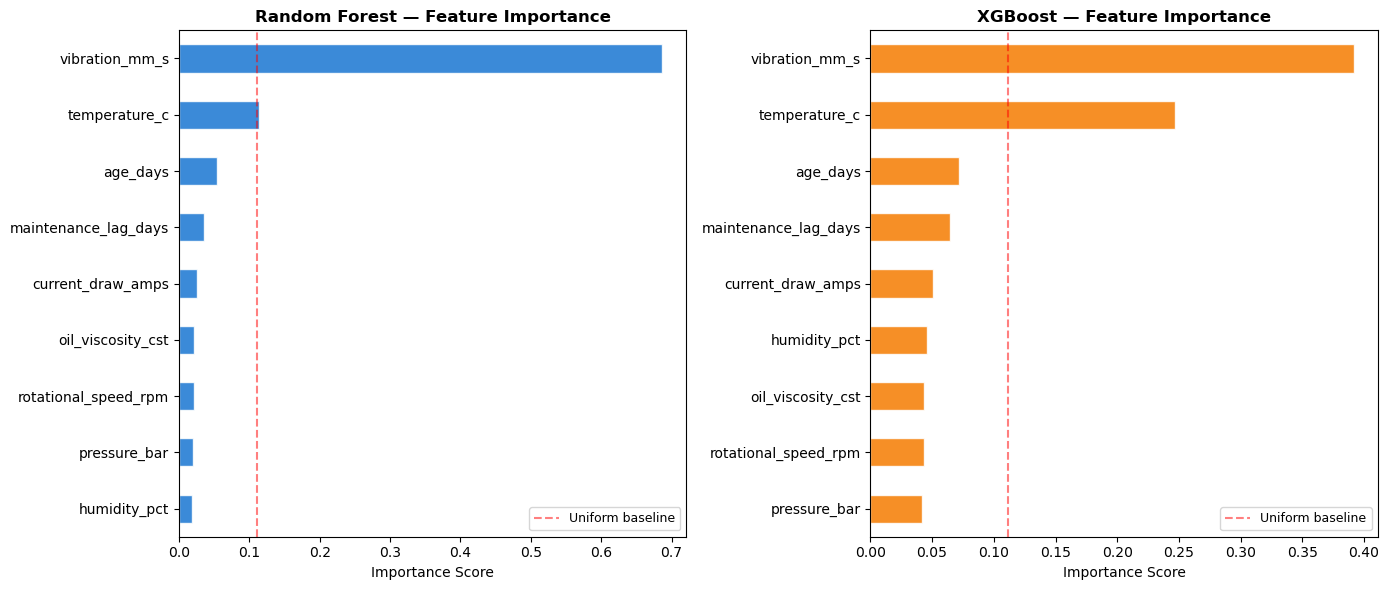

Top 3 drivers (XGBoost):
  vibration_mm_s: 0.3915
  temperature_c: 0.2466
  age_days: 0.0721


In [15]:
# ── Feature Importance — Both Models ──────────────────────────────────────────
# Feature importance tells us WHICH sensor readings drive failure predictions.
# This is critical for operations teams — they need to know WHERE to look.

rf_importance  = pd.Series(rf_model.feature_importances_,  index=FEATURES).sort_values(ascending=True)
xgb_importance = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rf_importance.plot(kind='barh',  ax=axes[0], color='#1976D2', alpha=0.85, edgecolor='white')
axes[0].set_title('Random Forest — Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].axvline(x=1/len(FEATURES), color='red', linestyle='--', alpha=0.5, label='Uniform baseline')
axes[0].legend(fontsize=9)

xgb_importance.plot(kind='barh', ax=axes[1], color='#F57C00', alpha=0.85, edgecolor='white')
axes[1].set_title('XGBoost — Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].axvline(x=1/len(FEATURES), color='red', linestyle='--', alpha=0.5, label='Uniform baseline')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 3 drivers (XGBoost):")
for feat, score in xgb_importance.sort_values(ascending=False).head(3).items():
    print(f"  {feat}: {score:.4f}")

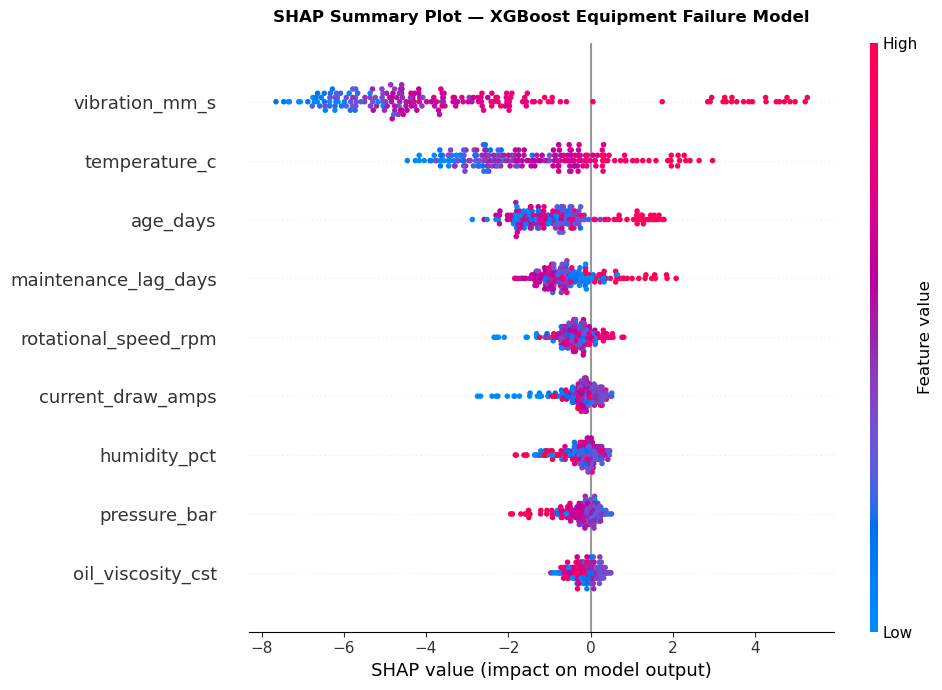

SHAP beeswarm: Each dot = one machine. Red = high feature value. Blue = low.
Dots to the RIGHT push the prediction toward failure.


In [16]:
# ── SHAP Values — Global Summary Plot ─────────────────────────────────────────
# SHAP (SHapley Additive exPlanations) explains HOW each feature pushes
# a prediction higher or lower. Unlike feature importance, SHAP shows
# DIRECTION (high vibration pushes prediction UP) and MAGNITUDE.
# This builds trust with the operations team — they can see the reasoning.

# Use a background sample for efficiency (100 samples is standard)
explainer = shap.TreeExplainer(xgb_model)
X_test_sample = X_test.sample(n=min(200, len(X_test)), random_state=SEED)
shap_values = explainer.shap_values(X_test_sample)

# Summary plot — beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_sample, feature_names=FEATURES,
                  show=False, plot_size=(10, 7))
plt.title('SHAP Summary Plot — XGBoost Equipment Failure Model', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP beeswarm: Each dot = one machine. Red = high feature value. Blue = low.")
print("Dots to the RIGHT push the prediction toward failure.")

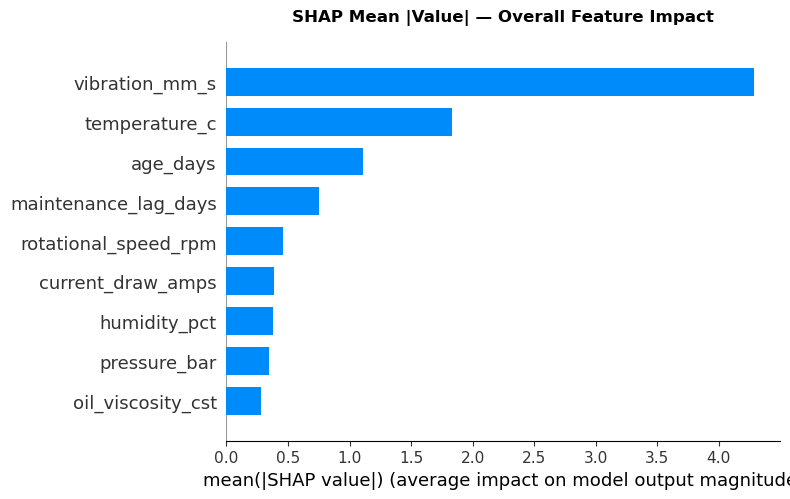

In [17]:
# ── SHAP Bar Plot (Mean Absolute) ──────────────────────────────────────────────
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test_sample, feature_names=FEATURES,
                  plot_type='bar', show=False)
plt.title('SHAP Mean |Value| — Overall Feature Impact', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

=== High-Risk Machine Explanation ===
Failure probability: 0.6%

Sensor readings:
  vibration_mm_s: 3.097
  temperature_c: 60.930
  pressure_bar: 4.321
  rotational_speed_rpm: 1732.300
  oil_viscosity_cst: 38.940
  current_draw_amps: 11.593
  humidity_pct: 66.300
  age_days: 155.000
  maintenance_lag_days: 2.000


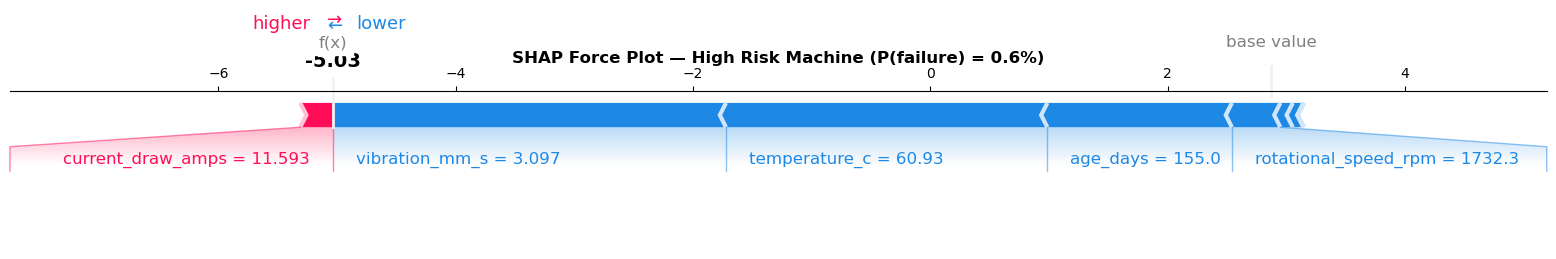


Red bars INCREASE failure probability. Blue bars DECREASE it.


In [18]:
# ── SHAP Force Plot — Single High-Risk Machine ─────────────────────────────────
# This is the KEY slide for the video walkthrough:
# We pick a specific machine flagged as HIGH RISK and explain WHY.

# Find the highest-risk machine in the test sample
high_risk_idx = xgb_prob[X_test.index.isin(X_test_sample.index)].argmax()
high_risk_local = np.where(X_test.index.isin(X_test_sample.index))[0][high_risk_idx]

risk_prob = xgb_model.predict_proba(
    X_test_sample.iloc[[high_risk_idx]])[0][1]

print(f"=== High-Risk Machine Explanation ===")
print(f"Failure probability: {risk_prob:.1%}")
print(f"\nSensor readings:")
for feat, val in X_test_sample.iloc[high_risk_idx].items():
    print(f"  {feat}: {val:.3f}")

# Force plot (HTML) — shows exactly what pushed this machine to HIGH RISK
shap.initjs()
force = shap.force_plot(
    explainer.expected_value,
    shap_values[high_risk_idx],
    X_test_sample.iloc[high_risk_idx],
    feature_names=FEATURES,
    matplotlib=True,
    show=False,
    figsize=(16, 3)
)
plt.title(f'SHAP Force Plot — High Risk Machine (P(failure) = {risk_prob:.1%})',
          fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_force_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nRed bars INCREASE failure probability. Blue bars DECREASE it.")

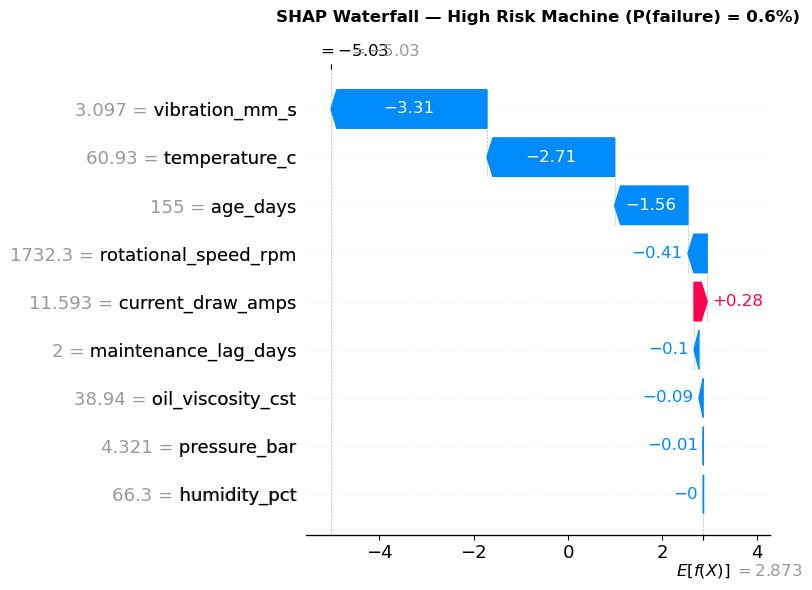

In [19]:
# ── SHAP Waterfall Plot ────────────────────────────────────────────────────────
# Waterfall shows contribution of each feature for one specific prediction

shap_explanation = shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test_sample.iloc[high_risk_idx].values,
    feature_names=FEATURES
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_explanation, show=False)
plt.title(f'SHAP Waterfall — High Risk Machine (P(failure) = {risk_prob:.1%})',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7 — Documentation & Final Summary

In [20]:
# ── Final Model Comparison Summary ────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

summary = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'CV ROC-AUC (mean)': [rf_cv_scores.mean(),  xgb_cv_scores.mean()],
    'CV ROC-AUC (std)':  [rf_cv_scores.std(),   xgb_cv_scores.std()],
    'Test ROC-AUC':      [roc_auc_score(y_test, rf_prob),
                          roc_auc_score(y_test, xgb_prob)],
    'Precision (fail)':  [precision_score(y_test, rf_pred),
                          precision_score(y_test, xgb_pred)],
    'Recall (fail)':     [recall_score(y_test, rf_pred),
                          recall_score(y_test, xgb_pred)],
    'F1 (fail)':         [f1_score(y_test, rf_pred),
                          f1_score(y_test, xgb_pred)],
}).round(4)

print("=" * 70)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 70)
print(summary.to_string(index=False))
print("\nWinner:", summary.loc[summary['Test ROC-AUC'].idxmax(), 'Model'])
print("\nKey Decision: We prioritise RECALL for the failure class.")
print("Missing a real failure (False Negative) is far more costly")
print("than a false alarm (False Positive) in this operational context.")

FINAL MODEL COMPARISON SUMMARY
        Model  CV ROC-AUC (mean)  CV ROC-AUC (std)  Test ROC-AUC  Precision (fail)  Recall (fail)  F1 (fail)
Random Forest             0.9840            0.0032        0.9698            0.5610         0.9583     0.7077
      XGBoost             0.9918            0.0016        0.9686            0.5114         0.9375     0.6618

Winner: Random Forest

Key Decision: We prioritise RECALL for the failure class.
Missing a real failure (False Negative) is far more costly
than a false alarm (False Positive) in this operational context.


In [21]:
# ── Save dataset for reference ─────────────────────────────────────────────────
df.drop(columns=['cluster']).to_csv('equipment_sensor_data.csv', index=False)
print(f"Dataset saved: equipment_sensor_data.csv ({len(df)} rows)")
print("\n=== Week 9 Assignment Complete ===")
print("Deliverables generated:")
print("  - week9_operational_ml.ipynb (this notebook)")
print("  - equipment_sensor_data.csv")
print("  - class_distribution.png")
print("  - correlation_matrix.png")
print("  - cv_comparison.png")
print("  - confusion_matrices.png")
print("  - roc_curves.png")
print("  - elbow_method.png")
print("  - clustering.png")
print("  - feature_importance.png")
print("  - shap_summary.png")
print("  - shap_bar.png")
print("  - shap_force_plot.png")
print("  - shap_waterfall.png")

Dataset saved: equipment_sensor_data.csv (3000 rows)

=== Week 9 Assignment Complete ===
Deliverables generated:
  - week9_operational_ml.ipynb (this notebook)
  - equipment_sensor_data.csv
  - class_distribution.png
  - correlation_matrix.png
  - cv_comparison.png
  - confusion_matrices.png
  - roc_curves.png
  - elbow_method.png
  - clustering.png
  - feature_importance.png
  - shap_summary.png
  - shap_bar.png
  - shap_force_plot.png
  - shap_waterfall.png
